<a href="https://colab.research.google.com/github/LUCASCAZANE/Proj1_Form_Cont_Caixa_Verso/blob/Proj1_Form_Cont_Caixa_Verso/projeto1_formacao_continuada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Pacote para criar marca d'agua imprimindo assim as versões dos pacotes
!pip install -q -U watermark

In [25]:
# Pacote para visualizar valores ausentes em uma variável
!pip install -q missingno

In [26]:
# Imports
# Primeira dupla para manipulação de dados
import pandas as pd
import numpy as np

# A Segunda dupla para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pacote para criar visualização dos valores ausentes
import missingno as msno

In [27]:
# Carregando o DF
df_FG_Sebrae = pd.read_csv("Op_Garantia_FG_BNDES_Sebrae.csv", sep=';')

In [28]:
# Visualizando as 10 primeiras linhas do df
df_FG_Sebrae.head(10)

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
0,BTG PACTUAL,**.*45.846/0001-**,M.A. COMERCIO DIGITAL LTDA,Micro,"97722,01","78177,61","97722,01",2026-04-14,MIRASSOL,SP,MIRASSOL,SP
1,BTG PACTUAL,**.*87.844/0001-**,SEA TEXTIL LTDA,Pequena,"117266,41","93813,13","117266,41",2026-04-14,INDAIAL,SC,INDAIAL,SC
2,BTG PACTUAL,**.*04.711/0001-**,M J LTDA,Micro,"14999,61","11999,69","14999,61",2026-04-14,FRANCISCO MORATO,SP,FRANCISCO MORATO,SP
3,BTG PACTUAL,**.*07.697/0001-**,POUSADA VILLA BILAC LTDA,Micro,"17262,08","13809,66","17262,08",2026-04-14,BLUMENAU,SC,BLUMENAU,SC
4,BTG PACTUAL,**.*16.091/0001-**,PATRICIA PET SHOP LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-15,CURITIBA,PR,CURITIBA,PR
5,BTG PACTUAL,**.*67.891/0001-**,JONATHAN OLIVEIRA CONSULTORIA IMOBILIARIA LTDA,Micro,"11716,88","9373,5","11716,88",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
6,BTG PACTUAL,**.*40.853/0001-**,GOIVA ARQUITETURA LTDA,Pequena,"42962,22","34369,78","42962,22",2026-04-15,SAO PAULO,SP,SAO PAULO,SP
7,BTG PACTUAL,**.*69.176/0001-**,J. P. CONSTRUCOES LTDA,Pequena,"26624,2","21299,36","26624,2",2026-04-15,CUIABA,MT,CUIABA,MT
8,BTG PACTUAL,**.*15.757/0001-**,PAPILIO GIFTS COMERCIO LTDA,Micro,"8592,64","6874,11","8592,64",2026-04-16,CURITIBA,PR,CURITIBA,PR
9,BTG PACTUAL,**.*47.568/0001-**,SILVIO FELIX MEDEIROS FILHO LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-16,PASSO FUNDO,RS,PASSO FUNDO,RS


In [29]:
# Numero (linhas e colunas)
df_FG_Sebrae.shape

(19302, 12)

In [30]:
# Informações
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nome_agente_financeiro      19302 non-null  str  
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str  
 2   nome_cliente                19302 non-null  str  
 3   porte_cliente               19070 non-null  str  
 4   valor_credito               19302 non-null  str  
 5   valor_garantido             19302 non-null  str  
 6   valor_desembolsado          19302 non-null  str  
 7   data_solicitacao_outorga    19302 non-null  str  
 8   municipio_investimento      19302 non-null  str  
 9   uf_investimento             19302 non-null  str  
 10  municipio_sede_cliente      19302 non-null  str  
 11  uf_sede_cliente             19302 non-null  str  
dtypes: str(12)
memory usage: 1.8 MB


In [31]:
# Descrevendo os dados não numéricos
df_FG_Sebrae.describe(include = object)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_464\2392548830.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_FG_Sebrae.describe(include = object)


,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
count,19302,19302,19302,19070,19302,19302,19302,19302,19302,19302,19302,19302
unique,5,16529,18092,2,4751,4750,2876,105,2726,27,2726,27
top,BRADESCO,**.*10.837/0001-**,LTDA,Pequena,"103993,34","83194,67","100000,0",2025-09-17,SAO PAULO,SP,SAO PAULO,SP
freq,18873,5,7,18232,459,459,934,2095,1605,5154,1605,5154


## Algumas informações que podemos aferir até aqui:
### 1.   Existem 5 nomes distintios de Agente Financeiro.
### 2.   Existem CPF/CNPJ duplicados (Pode ser que tenham mais de uma operação).
### 3.   Pequena Empresa é o porte com maior frequencia na Base de Dados.
### 4.   Valor de Credito que mais possui na BD é R$ 103.993,34 com 4751 registros (Pode ser o limite de credito para algum determinado segmento).
### 5.   O municipio do investimento/sede_cliente que mais possui registros é SÃO PAULO com 2726.

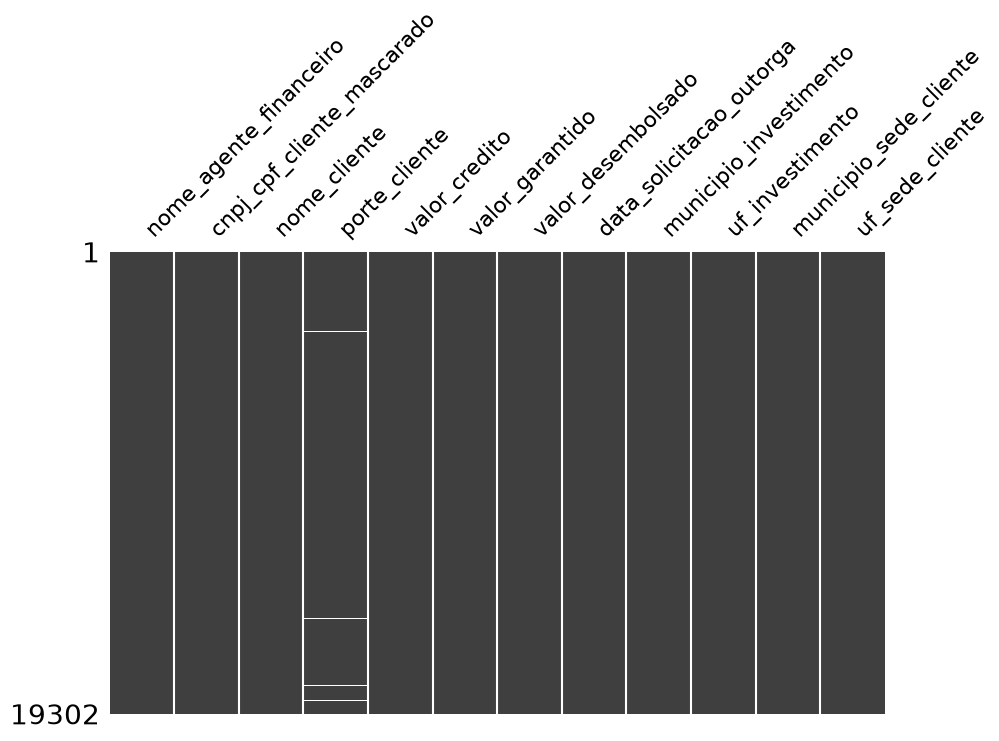

In [32]:
# Mapa de valores ausentes
msno.matrix(df_FG_Sebrae, figsize = (10, 6), sparkline = False)
plt.show()

In [33]:
# Usamos o método isna() para verificar valores ausentes em cada coluna
valores_ausentes = df_FG_Sebrae.isna().sum()
print("Valores ausentes por coluna:\n", valores_ausentes)

Valores ausentes por coluna:
 nome_agente_financeiro          0
cnpj_cpf_cliente_mascarado      0
nome_cliente                    0
porte_cliente                 232
valor_credito                   0
valor_garantido                 0
valor_desembolsado              0
data_solicitacao_outorga        0
municipio_investimento          0
uf_investimento                 0
municipio_sede_cliente          0
uf_sede_cliente                 0
dtype: int64


## Identificado 232 registros ausentes na variável 'porte_cliente'

In [34]:
# Investigando os tipos de dados das colunas do DataFrame
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nome_agente_financeiro      19302 non-null  str  
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str  
 2   nome_cliente                19302 non-null  str  
 3   porte_cliente               19070 non-null  str  
 4   valor_credito               19302 non-null  str  
 5   valor_garantido             19302 non-null  str  
 6   valor_desembolsado          19302 non-null  str  
 7   data_solicitacao_outorga    19302 non-null  str  
 8   municipio_investimento      19302 non-null  str  
 9   uf_investimento             19302 non-null  str  
 10  municipio_sede_cliente      19302 non-null  str  
 11  uf_sede_cliente             19302 non-null  str  
dtypes: str(12)
memory usage: 1.8 MB


In [35]:
# Visualizando os valores da coluna 'data_solicitacao_outorga' para ajustar o tipo de dado
df_FG_Sebrae['data_solicitacao_outorga'].head() 

0    2026-04-14
1    2026-04-14
2    2026-04-14
3    2026-04-14
4    2026-04-15
Name: data_solicitacao_outorga, dtype: str

In [36]:
# Alterando o tipo de dado da coluna 'data_solicitacao_outorga' para datetime
df_FG_Sebrae["data_solicitacao_outorga"] = pd.to_datetime(
    df_FG_Sebrae["data_solicitacao_outorga"],
    format="%Y-%m-%d"
)

In [37]:
#Conferindo a alteração.
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  str           
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str           
 2   nome_cliente                19302 non-null  str           
 3   porte_cliente               19070 non-null  str           
 4   valor_credito               19302 non-null  str           
 5   valor_garantido             19302 non-null  str           
 6   valor_desembolsado          19302 non-null  str           
 7   data_solicitacao_outorga    19302 non-null  datetime64[us]
 8   municipio_investimento      19302 non-null  str           
 9   uf_investimento             19302 non-null  str           
 10  municipio_sede_cliente      19302 non-null  str           
 11  uf_sede_cliente             19302 non-null  str           
dtypes

In [38]:
df_FG_Sebrae['data_solicitacao_outorga'].head()

0   2026-04-14
1   2026-04-14
2   2026-04-14
3   2026-04-14
4   2026-04-15
Name: data_solicitacao_outorga, dtype: datetime64[us]

In [39]:
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  str           
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str           
 2   nome_cliente                19302 non-null  str           
 3   porte_cliente               19070 non-null  str           
 4   valor_credito               19302 non-null  str           
 5   valor_garantido             19302 non-null  str           
 6   valor_desembolsado          19302 non-null  str           
 7   data_solicitacao_outorga    19302 non-null  datetime64[us]
 8   municipio_investimento      19302 non-null  str           
 9   uf_investimento             19302 non-null  str           
 10  municipio_sede_cliente      19302 non-null  str           
 11  uf_sede_cliente             19302 non-null  str           
dtypes

In [40]:
df_FG_Sebrae.head()

,nome_agente_financeiro,cnpj_cpf_cliente_mascarado,nome_cliente,porte_cliente,valor_credito,valor_garantido,valor_desembolsado,data_solicitacao_outorga,municipio_investimento,uf_investimento,municipio_sede_cliente,uf_sede_cliente
0,BTG PACTUAL,**.*45.846/0001-**,M.A. COMERCIO DIGITAL LTDA,Micro,"97722,01","78177,61","97722,01",2026-04-14,MIRASSOL,SP,MIRASSOL,SP
1,BTG PACTUAL,**.*87.844/0001-**,SEA TEXTIL LTDA,Pequena,"117266,41","93813,13","117266,41",2026-04-14,INDAIAL,SC,INDAIAL,SC
2,BTG PACTUAL,**.*04.711/0001-**,M J LTDA,Micro,"14999,61","11999,69","14999,61",2026-04-14,FRANCISCO MORATO,SP,FRANCISCO MORATO,SP
3,BTG PACTUAL,**.*07.697/0001-**,POUSADA VILLA BILAC LTDA,Micro,"17262,08","13809,66","17262,08",2026-04-14,BLUMENAU,SC,BLUMENAU,SC
4,BTG PACTUAL,**.*16.091/0001-**,PATRICIA PET SHOP LTDA,Micro,"10154,76","8123,81","10154,76",2026-04-15,CURITIBA,PR,CURITIBA,PR


In [ ]:
# Alterando o tipo de dado das colunas de valor para decimal (float)
colunas_valor = [
    "valor_credito",
    "valor_garantido",
    "valor_desembolsado"
]

for coluna in colunas_valor:
    df_FG_Sebrae[coluna] = (
        df_FG_Sebrae[coluna]
        .astype("string")
        .str.strip()                                                # Remove espaços antes e depois do valor
        .str.replace(".", "", regex=False)                          # Remove o ponto usado como separador de milhar
        .str.replace(",", ".", regex=False)                         # Substitui vírgula por ponto como separador decimal
        .pipe(pd.to_numeric, errors="coerce")                       # Converte para número; valores inválidos viram NaN
        .astype("float64")                                          # Define explicitamente a coluna como decimal (float)
    )

In [ ]:
# Conferindo a alteração.
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  str           
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str           
 2   nome_cliente                19302 non-null  str           
 3   porte_cliente               19070 non-null  str           
 4   valor_credito               19302 non-null  float64       
 5   valor_garantido             19302 non-null  float64       
 6   valor_desembolsado          19302 non-null  float64       
 7   data_solicitacao_outorga    19302 non-null  datetime64[us]
 8   municipio_investimento      19302 non-null  str           
 9   uf_investimento             19302 non-null  str           
 10  municipio_sede_cliente      19302 non-null  str           
 11  uf_sede_cliente             19302 non-null  str           
dtypes

In [48]:
df_FG_Sebrae["porte_cliente"].unique()  # Exibe os valores únicos da coluna

<StringArray>
['Micro', 'Pequena', nan]
Length: 3, dtype: str

In [45]:
df_FG_Sebrae["porte_cliente"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

porte_cliente
Pequena    18232
Micro        838
NaN          232
Name: count, dtype: int64

In [49]:
df_FG_Sebrae["uf_investimento"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

uf_investimento
SP    5154
BA    1544
MG    1421
PR    1332
MA     932
PA     883
CE     880
GO     828
RJ     824
RS     677
PE     658
AM     549
SC     536
MT     432
MS     410
TO     349
PI     275
PB     264
ES     223
RN     222
DF     220
AL     205
RO     161
SE     113
RR      84
AC      76
AP      50
Name: count, dtype: int64

In [51]:
df_FG_Sebrae["uf_sede_cliente"].value_counts(dropna=False)  # Exibe cada valor distinto e sua quantidade, incluindo nulos

uf_sede_cliente
SP    5154
BA    1544
MG    1421
PR    1332
MA     932
PA     883
CE     880
GO     828
RJ     824
RS     677
PE     658
AM     549
SC     536
MT     432
MS     410
TO     349
PI     275
PB     264
ES     223
RN     222
DF     220
AL     205
RO     161
SE     113
RR      84
AC      76
AP      50
Name: count, dtype: int64

In [52]:
colunas_categoria = [  # Colunas com bastante valores repetidos
    "porte_cliente",
    "uf_investimento",
    "uf_sede_cliente"
]

for coluna in colunas_categoria:
    df_FG_Sebrae[coluna] = df_FG_Sebrae[coluna].astype("category")  # Converte texto repetitivo em categoria

In [53]:
df_FG_Sebrae.info()

<class 'pandas.DataFrame'>
RangeIndex: 19302 entries, 0 to 19301
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   nome_agente_financeiro      19302 non-null  str           
 1   cnpj_cpf_cliente_mascarado  19302 non-null  str           
 2   nome_cliente                19302 non-null  str           
 3   porte_cliente               19070 non-null  category      
 4   valor_credito               19302 non-null  float64       
 5   valor_garantido             19302 non-null  float64       
 6   valor_desembolsado          19302 non-null  float64       
 7   data_solicitacao_outorga    19302 non-null  datetime64[us]
 8   municipio_investimento      19302 non-null  str           
 9   uf_investimento             19302 non-null  category      
 10  municipio_sede_cliente      19302 non-null  str           
 11  uf_sede_cliente             19302 non-null  category      
dtypes